In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [18]:
stroke = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")

In [19]:
stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [20]:
stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [21]:
stroke.shape

(5110, 12)

In [22]:
stroke.columns.tolist()

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

In [23]:
stroke = stroke.drop(columns=["id"])

In [24]:
stroke.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [25]:
stroke["bmi"] = stroke["bmi"].fillna(stroke["bmi"].median())

In [26]:
stroke = pd.get_dummies(
    stroke,
    columns=[
        "gender",
        "ever_married",
        "work_type",
        "Residence_type",
        "smoking_status"
    ],
    drop_first=True
)

In [27]:
X = stroke.drop(columns=["stroke"])
y = stroke["stroke"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Stroke model trained successfully!")

Stroke model trained successfully!


In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9393346379647749


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Reds")

plt.title("Stroke Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

NameError: name 'cm' is not defined

<Figure size 600x500 with 0 Axes>

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[960   0]
 [ 62   0]]


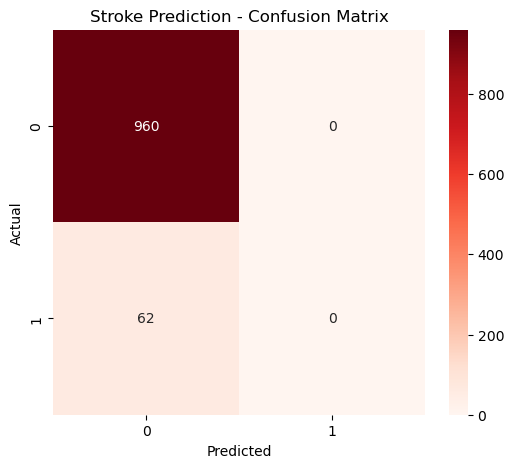

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Stroke Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
print(cm)

[[960   0]
 [ 62   0]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print(importance.head(15))

                           Feature  Coefficient
11              work_type_children     0.687994
1                     hypertension     0.346446
2                    heart_disease     0.265449
15           smoking_status_smokes     0.190983
9                work_type_Private     0.152211
0                              age     0.074616
12            Residence_type_Urban     0.028998
5                      gender_Male     0.017493
3                avg_glucose_level     0.003829
4                              bmi     0.002052
6                     gender_Other     0.000000
13  smoking_status_formerly smoked    -0.057724
8           work_type_Never_worked    -0.073832
14     smoking_status_never smoked    -0.121939
10         work_type_Self-employed    -0.238073


In [39]:
import joblib

joblib.dump(model, "stroke_model.pkl")

print("Stroke model saved successfully!")

Stroke model saved successfully!


In [40]:
import joblib

joblib.dump(model, "stroke_model.pkl")

print("Stroke model saved successfully!")

Stroke model saved successfully!


# Conclusion

The Stroke Prediction model was successfully developed using Logistic Regression. Missing values in the BMI column were handled using median imputation, and categorical variables were encoded using one-hot encoding. The model was evaluated using Accuracy, Confusion Matrix, and Classification Report. The trained model was saved successfully for future deployment in the Silent Health Risk Detector for Women.

In [41]:
print(X.columns.tolist())

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [42]:
print(X.shape)

(5110, 16)


In [43]:
print(model.feature_names_in_)

['age' 'hypertension' 'heart_disease' 'avg_glucose_level' 'bmi'
 'gender_Male' 'gender_Other' 'ever_married_Yes' 'work_type_Never_worked'
 'work_type_Private' 'work_type_Self-employed' 'work_type_children'
 'Residence_type_Urban' 'smoking_status_formerly smoked'
 'smoking_status_never smoked' 'smoking_status_smokes']
